In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, activations
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import cv2
import numpy as np
import time
import random
import math
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
class SinusoidalEmbedding(layers.Layer):
    def __init__(self, embedding_dim=128):
        super().__init__()
        self.embedding_dim = embedding_dim

    def call(self, timesteps):
        half_dim = self.embedding_dim // 2
        exponent = -tf.math.log(10000.0) / (half_dim - 1)
        embedding_basis = tf.exp(tf.range(half_dim, dtype=tf.float32) * exponent)
        timesteps_float = tf.cast(timesteps, dtype=tf.float32)
        embeddings = tf.concat([
            tf.sin(timesteps_float[:, None] * embedding_basis[None, :]),
            tf.cos(timesteps_float[:, None] * embedding_basis[None, :])
        ], axis=-1)
        return embeddings

class FeaturewiseAffine(layers.Layer):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.dense = layers.Dense(dim * 2)

    def call(self, cond, x):
        gamma_beta = self.dense(cond)
        # Use Keras backend's split wrapper instead of raw tf.split
        gamma, beta = tf.split(gamma_beta, num_or_size_splits=2, axis=-1)
        gamma = tf.reshape(gamma, [-1, 1, 1, self.dim])
        beta = tf.reshape(beta, [-1, 1, 1, self.dim])
        return gamma * x + beta

class GroupNorm(layers.Layer):
    def __init__(self, groups=32, axis=-1, epsilon=1e-5):
        super().__init__()
        self.groups = groups
        self.axis = axis
        self.epsilon = epsilon

    def build(self, input_shape):
        self.gamma = self.add_weight(name='gamma', shape=(input_shape[self.axis],), initializer='ones', trainable=True)
        self.beta = self.add_weight(name='beta', shape=(input_shape[self.axis],), initializer='zeros', trainable=True)

    def call(self, x):
        input_shape = tf.shape(x)
        N, H, W, C = input_shape[0], input_shape[1], input_shape[2], input_shape[3]
        G = tf.minimum(self.groups, C)
        x = tf.reshape(x, [N, H, W, G, C // G])
        mean, var = tf.nn.moments(x, [1, 2, 4], keepdims=True)
        x = (x - mean) / tf.sqrt(var + self.epsilon)
        x = tf.reshape(x, [N, H, W, C])
        return self.gamma * x + self.beta

def downsample(x, filters):
    return layers.Conv2D(filters, 3, strides=2, padding='same')(x)

def upsample(x, filters):
    x = layers.UpSampling2D()(x)
    return layers.Conv2D(filters, 3, padding='same')(x)

def resnet_block(x, cond, filters, groups=32, dropout_rate=0.4):
    h = GroupNorm(groups=groups)(x)
    h = layers.Activation(activations.silu)(h)
    h = layers.Conv2D(filters, 3, padding='same')(h)

    featurewise_affine = FeaturewiseAffine(filters)
    h = featurewise_affine(cond, h)
    h = GroupNorm(groups=groups)(h)
    h = layers.Activation(activations.silu)(h)
    h = layers.Dropout(dropout_rate)(h)  # Dropout layer added here with 40% rate
    h = layers.Conv2D(filters, 3, padding='same')(h)
    if x.shape[-1] != filters:
        x = layers.Conv2D(filters, 1, padding='same')(x)
    return layers.Add()([x, h])

def build_sr3_unet(input_shape=(128,128,6), time_emb_dim=128):

    inputs = layers.Input(shape=input_shape)
    time_input = layers.Input(shape=(), dtype=tf.int32)

    time_emb_layer = SinusoidalEmbedding(time_emb_dim)
    time_embedding = time_emb_layer(time_input)

    # Time embedding MLP
    t = layers.Dense(time_emb_dim * 4, activation='silu')(time_embedding)
    t = layers.Dense(time_emb_dim)(t)

    # Encoder
    x1 = layers.Conv2D(64, 3, padding='same')(inputs)
    x1 = resnet_block(x1, t, 64)
    x2 = downsample(x1, 128)
    x2 = resnet_block(x2, t, 128)
    x3 = downsample(x2, 256)
    x3 = resnet_block(x3, t, 256)
    x4 = downsample(x3, 512)
    x4 = resnet_block(x4, t, 512)

    # Bottleneckdim
    b = downsample(x4, 512)
    b = resnet_block(b, t, 512)

    # Decoder
    u1 = upsample(b, 512)
    u1 = layers.Concatenate()([u1, x4])
    u1 = resnet_block(u1, t, 512)
    u2 = upsample(u1, 256)
    u2 = layers.Concatenate()([u2, x3])
    u2 = resnet_block(u2, t, 256)
    u3 = upsample(u2, 128)
    u3 = layers.Concatenate()([u3, x2])
    u3 = resnet_block(u3, t, 128)
    u4 = upsample(u3, 64)
    u4 = layers.Concatenate()([u4, x1])
    u4 = resnet_block(u4, t, 64)

    outputs = layers.Conv2D(3, 1, padding='same')(u4)

    return Model(inputs=[inputs, time_input], outputs=outputs)

In [ ]:
def cosine_beta_schedule(timesteps, s=0.008):
    steps = timesteps + 1
    x = tf.linspace(0.0, timesteps, steps)
    alphas_cumprod = tf.cos(((x / timesteps) + s) / (1 + s) * tf.constant(np.pi) * 0.5)**2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return tf.clip_by_value(betas, 0.0001, 0.999)

def add_noise(image, timestep, sqrt_alphas_cumprod, sqrt_one_minus_alpha_cumprod):
    sqrt_alphas_cumprod_t = tf.gather(sqrt_alphas_cumprod, timestep)
    sqrt_alphas_cumprod_t = tf.reshape(sqrt_alphas_cumprod_t, [-1, 1, 1, 1])

    sqrt_one_minus_alphas_cumprod_t = tf.gather(sqrt_one_minus_alpha_cumprod, timestep)
    sqrt_one_minus_alphas_cumprod_t = tf.reshape(sqrt_one_minus_alphas_cumprod_t, [-1, 1, 1, 1])

    noise = tf.random.normal(shape=tf.shape(image))
    noisy_image = sqrt_alphas_cumprod_t * image + sqrt_one_minus_alphas_cumprod_t * noise
    return noisy_image, noise

In [ ]:
def prepare_diffusion_buffers(betas):
    alphas = 1.0 - betas
    alphas_cumprod = tf.math.cumprod(alphas, axis=0)
    alphas_cumprod_prev = tf.concat([tf.constant([1.0], dtype=tf.float32), alphas_cumprod[:-1]], axis=0)
    sqrt_alphas_cumprod = tf.sqrt(alphas_cumprod)
    sqrt_one_minus_alphas_cumprod = tf.sqrt(1.0 - alphas_cumprod)
    sqrt_recip_alphas_cumprod = tf.sqrt(1.0 / alphas_cumprod)
    sqrt_recipm1_alphas_cumprod = tf.sqrt(1.0 / alphas_cumprod - 1)
    posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
    posterior_log_variance_clipped = tf.math.log(tf.maximum(posterior_variance, 1e-20))
    posterior_mean_coef1 = betas * tf.sqrt(alphas_cumprod_prev) / (1.0 - alphas_cumprod)
    posterior_mean_coef2 = (1.0 - alphas_cumprod_prev) * tf.sqrt(alphas) / (1.0 - alphas_cumprod)
    return {
        'betas': betas,
        'alphas_cumprod': alphas_cumprod,
        'alphas_cumprod_prev': alphas_cumprod_prev,
        'sqrt_alphas_cumprod': sqrt_alphas_cumprod,
        'sqrt_one_minus_alphas_cumprod': sqrt_one_minus_alphas_cumprod,
        'sqrt_recip_alphas_cumprod': sqrt_recip_alphas_cumprod,
        'sqrt_recipm1_alphas_cumprod': sqrt_recipm1_alphas_cumprod,
        'posterior_variance': posterior_variance,
        'posterior_log_variance_clipped': posterior_log_variance_clipped,
        'posterior_mean_coef1': posterior_mean_coef1,
        'posterior_mean_coef2': posterior_mean_coef2,
    }

def predict_start_from_noise(x_t, t, noise, buffers):
    sqrt_recip_alphas_cumprod = tf.gather(buffers['sqrt_recip_alphas_cumprod'], t)
    sqrt_recipm1_alphas_cumprod = tf.gather(buffers['sqrt_recipm1_alphas_cumprod'], t)
    return sqrt_recip_alphas_cumprod * x_t - sqrt_recipm1_alphas_cumprod * noise

def p_sample(x, t, model, lr_image, buffers, training=False):
    batch_size = tf.shape(x)[0]
    model_image_input = tf.concat([lr_image, x], axis=-1)
    t_tensor = tf.fill([batch_size], t)
    predicted_noise = model([model_image_input, t_tensor], training=training)
    x0_pred = predict_start_from_noise(x, t, predicted_noise, buffers)
    coef1 = tf.gather(buffers['posterior_mean_coef1'], t)
    coef2 = tf.gather(buffers['posterior_mean_coef2'], t)
    posterior_mean = coef1 * x0_pred + coef2 * x
    log_variance = tf.gather(buffers['posterior_log_variance_clipped'], t)
    noise = tf.random.normal(shape=tf.shape(x)) if t > 0 else 0.0
    return posterior_mean + tf.exp(0.5 * log_variance) * noise

def sr3_sampling(lr_image, model, timesteps=1000, sampling_steps=None):
    if len(tf.shape(lr_image)) == 3:
        lr_image = tf.expand_dims(lr_image, axis=0)
    batch_size = tf.shape(lr_image)[0]
    height, width, channels = tf.shape(lr_image)[1], tf.shape(lr_image)[2], tf.shape(lr_image)[3]

    betas = cosine_beta_schedule(timesteps)
    buffers = prepare_diffusion_buffers(betas)
    if sampling_steps is None:
        sampling_steps = timesteps
    sample_timesteps = np.linspace(timesteps - 1, 0, sampling_steps, dtype=np.int32)
    x_t = tf.random.normal(shape=(batch_size, height, width, channels))

    for t in sample_timesteps:
        x_t = p_sample(x_t, t, model, lr_image, buffers, training=False)
        x_t = tf.clip_by_value(x_t, 0.0, 1.0)

    return x_t

In [ ]:
def visualize_sample(model, dataset, timesteps, epoch=None, save_dir=None, num_samples=3):
    all_psnr, all_ssim = [], []

    for lr_batch, hr_batch in dataset.take(1):
        for i in range(min(num_samples, lr_batch.shape[0])):
            lr_img = lr_batch[i:i+1]
            hr_img = hr_batch[i:i+1]
            sample_output = sr3_sampling(lr_img, model, timesteps)  # SR output

            # Convert tensors to numpy arrays and squeeze batch dim
            lr_img_np = tf.squeeze(lr_img).numpy()
            sr_img_np = tf.squeeze(sample_output).numpy()
            hr_img_np = tf.squeeze(hr_img).numpy()

            psnr_val = tf.image.psnr(sr_img_np, hr_img_np, max_val=1.0)
            ssim_val = tf.image.ssim(sr_img_np, hr_img_np, max_val=1.0)
            all_psnr.append(psnr_val.numpy())
            all_ssim.append(ssim_val.numpy())

            # Show LR, SR, HR side-by-side for only the first sample i==0
            if i == 0:
                plt.figure(figsize=(12, 4))
                titles = ['LR Input', 'SR Output', 'HR Ground Truth']
                images = [lr_img_np, sr_img_np, hr_img_np]
                for j in range(3):
                    plt.subplot(1, 3, j + 1)
                    plt.imshow(np.clip(images[j], 0, 1))
                    plt.title(titles[j])
                    plt.axis('off')
                plt.tight_layout()

                if save_dir and epoch is not None:
                    os.makedirs(save_dir, exist_ok=True)
                    image_path = os.path.join(save_dir, f"epoch_{epoch+1}_sample_{i+1}.png")
                    plt.savefig(image_path)
                    print(f"Saved visualization: {image_path}")

                plt.show()

    mean_psnr = np.mean(all_psnr)
    mean_ssim = np.mean(all_ssim)
    print(f"Metrics for epoch {epoch+1 if epoch else '?'}: Mean PSNR = {mean_psnr}, Mean SSIM = {mean_ssim}")


In [ ]:
def compress_and_save_images(hr_dir, output_base_dir, quality_levels=[10, 30, 50]):

    if not os.path.exists(output_base_dir):
        os.makedirs(output_base_dir)
        print(f"Created output directory: {output_base_dir}")

    hr_image_paths = sorted([
        os.path.join(hr_dir, f) for f in os.listdir(hr_dir)
        if f.lower().endswith('.png')
    ])

    if not hr_image_paths:
        print(f"No PNG images found in {hr_dir}. Please check the directory and file extensions.")
        return

    print(f"Found {len(hr_image_paths)} HR images.")

    for hr_path in hr_image_paths:
        filename = os.path.basename(hr_path)
        name, _ = os.path.splitext(filename)

        # Read HR image using OpenCV
        hr_img = cv2.imread(hr_path, cv2.IMREAD_COLOR)

        if hr_img is None:
            print(f"Warning: Could not read image {hr_path}. Skipping.")
            continue

        for quality in quality_levels:
            quality_output_dir = os.path.join(output_base_dir, str(quality))
            if not os.path.exists(quality_output_dir):
                os.makedirs(quality_output_dir)

            output_filename = f"{name}_q{quality}.jpg"
            output_path = os.path.join(quality_output_dir, output_filename)

            success = cv2.imwrite(output_path, hr_img, [int(cv2.IMWRITE_JPEG_QUALITY), quality])

            if success:
                print(f"Compressed {filename} at quality {quality} and saved to {output_path}")
            else:
                print(f"Error compressing {filename} at quality {quality}.")

    print("Compression process finished.")

In [ ]:
#rm -r /content/compressed_div2k_val brisanje direktorija i njegovih sadržaja ako dođe do greške u
# idućem bloku komandi

In [ ]:
hr_image_train_dir = '/content/drive/MyDrive/Datasets/Dataset/DIV2K_train_HR'
hr_image_val_dir = '/content/drive/MyDrive/Datasets/Dataset/DIV2K_valid_HR'
hr_image_test_dir = '/content/drive/MyDrive/Datasets/Dataset/DIV2K_test_HR'

compressed_output_train_dir = '/content/compressed_div2k_train'
compressed_output_val_dir = '/content/compressed_div2k_val'
compressed_output_test_dir = '/content/compressed_div2k_test'

# Predefinirane razine kvalitete su 10, 30 i 50% kako je navedeno u mailu za zadatak
compress_and_save_images(hr_image_train_dir, compressed_output_train_dir)
compress_and_save_images(hr_image_val_dir, compressed_output_val_dir)
compress_and_save_images(hr_image_test_dir, compressed_output_test_dir)

Created output directory: /content/compressed_div2k_train
Found 700 HR images.
Compressed 0001.png at quality 10 and saved to /content/compressed_div2k_train/10/0001_q10.jpg
Compressed 0001.png at quality 30 and saved to /content/compressed_div2k_train/30/0001_q30.jpg
Compressed 0001.png at quality 50 and saved to /content/compressed_div2k_train/50/0001_q50.jpg
Compressed 0002.png at quality 10 and saved to /content/compressed_div2k_train/10/0002_q10.jpg
Compressed 0002.png at quality 30 and saved to /content/compressed_div2k_train/30/0002_q30.jpg
Compressed 0002.png at quality 50 and saved to /content/compressed_div2k_train/50/0002_q50.jpg
Compressed 0003.png at quality 10 and saved to /content/compressed_div2k_train/10/0003_q10.jpg
Compressed 0003.png at quality 30 and saved to /content/compressed_div2k_train/30/0003_q30.jpg
Compressed 0003.png at quality 50 and saved to /content/compressed_div2k_train/50/0003_q50.jpg
Compressed 0004.png at quality 10 and saved to /content/compressed

In [ ]:
def compare_jpeg_patch_quality(image_path, quality_list=[10, 20, 30, 40], patch_size=256):
    # Read and convert image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape

    # Select a random patch position
    y = np.random.randint(0, h - patch_size)
    x = np.random.randint(0, w - patch_size)

    patch_slices = (slice(y, y+patch_size), slice(x, x+patch_size))

    patches = []
    labels = []

    for q in quality_list:
        # JPEG compress & decompress
        _, enc = cv2.imencode('.jpg', image, [int(cv2.IMWRITE_JPEG_QUALITY), q])
        compressed = cv2.imdecode(enc, cv2.IMREAD_COLOR)
        #compressed = cv2.cvtColor(compressed, cv2.COLOR_BGR2RGB)

        patch = compressed[patch_slices]
        patches.append(patch)
        labels.append(f'Quality {q}')

    # Original patch for reference
    orig_patch = image[patch_slices]
    patches.insert(0, orig_patch)
    labels.insert(0, 'Original')

    # Show patches side-by-side
    plt.figure(figsize=(3*len(patches), 3))
    for i, (patch, label) in enumerate(zip(patches, labels)):
        plt.subplot(1, len(patches), i+1)
        plt.imshow(patch)
        plt.title(label)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

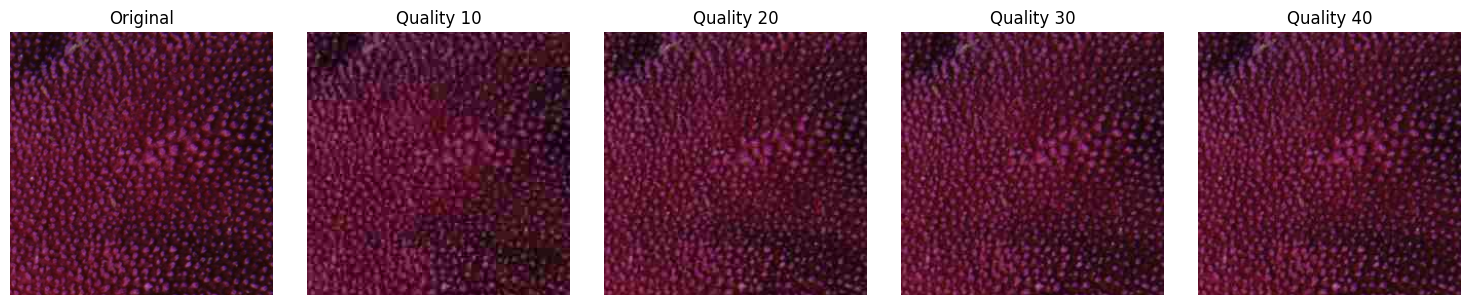

In [ ]:
compare_jpeg_patch_quality('/content/drive/MyDrive/Datasets/Dataset/DIV2K_train_HR/0001.png')

In [ ]:
def create_dataset(hr_dir, lr_dir, quality_levels, hr_patch_size=256, batch_size=16):
    hr_image_paths = sorted([os.path.join(hr_dir, f) for f in os.listdir(hr_dir)])

    dataset_pairs = []
    for hr_path in hr_image_paths:
        filename = os.path.basename(hr_path)
        name, _ = os.path.splitext(filename)
        quality = random.choice(quality_levels)
        lr_filename = f"{name}_q{quality}.jpg"
        lr_path = os.path.join(lr_dir, str(quality), lr_filename)
        if os.path.exists(lr_path):
            dataset_pairs.append((hr_path, lr_path))

    if not dataset_pairs:
        raise ValueError("No valid hr-lr image pairs found.")

    hr_paths, lr_paths = zip(*dataset_pairs)
    path_dataset = tf.data.Dataset.from_tensor_slices((list(hr_paths), list(lr_paths)))

    def process_path(hr_path, lr_path):
        hr_img = tf.io.read_file(hr_path)
        hr_img = tf.image.decode_png(hr_img, channels=3)
        hr_img = tf.image.convert_image_dtype(hr_img, tf.float32)

        lr_img = tf.io.read_file(lr_path)
        lr_img = tf.image.decode_jpeg(lr_img, channels=3)
        lr_img = tf.image.convert_image_dtype(lr_img, tf.float32)

        crop_size = hr_patch_size

        hr_shape = tf.shape(hr_img)[:2]
        lr_shape = tf.shape(lr_img)[:2]

        max_x = lr_shape[1] - crop_size
        max_y = lr_shape[0] - crop_size
        x = tf.random.uniform([], 0, max_x + 1, dtype=tf.int32)
        y = tf.random.uniform([], 0, max_y + 1, dtype=tf.int32)

        lr_patch = tf.image.crop_to_bounding_box(lr_img, y, x, crop_size, crop_size)
        hr_patch = tf.image.crop_to_bounding_box(hr_img, y, x, crop_size, crop_size)

        return lr_patch, hr_patch

    dataset = path_dataset.shuffle(buffer_size=len(dataset_pairs)).map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)

    return dataset

In [ ]:
@tf.function
def train_step(hr_batch, lr_batch, model, timesteps, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod):
    batch_size = tf.shape(hr_batch)[0]

    t = tf.random.uniform(shape=[batch_size], minval=0, maxval=timesteps, dtype=tf.int32)

    noisy_hr_batch, noise = add_noise(hr_batch, t, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod)

    lr_up = tf.image.resize(lr_batch, tf.shape(hr_batch)[1:3], method="bicubic")

    model_input = tf.concat([lr_batch, noisy_hr_batch], axis=-1)

    with tf.GradientTape() as tape:
        predicted_noise = model([model_input, t], training=True)
        loss = loss_fn(noise, predicted_noise)

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss

In [ ]:
@tf.function
def validation_step(hr_batch, lr_batch, model, timesteps, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod):
    batch_size = tf.shape(hr_batch)[0]

    t = tf.random.uniform(shape=[batch_size], minval=0, maxval=timesteps, dtype=tf.int32)

    noisy_hr_batch, noise = add_noise(hr_batch, t, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod)

    model_image_input = tf.concat([lr_batch, noisy_hr_batch], axis=-1)

    predicted_noise = model([model_image_input, t], training=False)
    val_loss = loss_fn(noise, predicted_noise)

    return val_loss

In [ ]:
#@tf.function
def init_optimizer(model, optimizer, buffers):
    dummy_hr = tf.zeros((1, hr_patch_size, hr_patch_size, 3))
    dummy_lr = tf.zeros((1, hr_patch_size, hr_patch_size, 3))  # No scaling needed now

    t = tf.constant([0], dtype=tf.int32)

    # Use precomputed buffers from your schedule
    noisy_hr, noise = add_noise(dummy_hr, t, buffers['sqrt_alphas_cumprod'], buffers['sqrt_one_minus_alphas_cumprod'])

    model_input = tf.concat([dummy_lr, noisy_hr], axis=-1)

    with tf.GradientTape() as tape:
        predicted = model([model_input, t], training=True)
        loss = loss_fn(noise, predicted)

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    return loss

In [ ]:
def convert_buffers_to_float32(buffers):
    new_buffers = {}
    for k, v in buffers.items():
        # Convert to tf.float32
        if isinstance(v, tf.Tensor):
            new_buffers[k] = tf.cast(v, tf.float32)
        elif isinstance(v, (np.ndarray, list)):
            # Convert numpy or list to tf.float32 tensor
            new_buffers[k] = tf.convert_to_tensor(v, dtype=tf.float32)
        else:
            new_buffers[k] = v  # keep other types unchanged
    return new_buffers

In [ ]:
class WarmupCosineDecayScheduler(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, total_steps, warmup_steps=5000, min_lr=1e-6):
        super().__init__()
        self.base_lr = base_lr
        self.total_steps = total_steps
        self.warmup_steps = warmup_steps
        self.min_lr = min_lr

    def __call__(self, step):
        # Linear warmup
        warmup_lr = self.base_lr * (step / self.warmup_steps)
        warmup_lr = tf.where(step < self.warmup_steps, warmup_lr, self.base_lr)

        # Cosine decay after warmup
        progress = (step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
        cosine_decay = 0.5 * (1 + tf.cos(math.pi * progress))
        decayed_lr = self.min_lr + (self.base_lr - self.min_lr) * cosine_decay
        lr = tf.where(step < self.warmup_steps, warmup_lr, decayed_lr)

        return lr

In [ ]:
# --- Main Training Loop Setup ---
train_hr_dir = '/content/drive/MyDrive/Datasets/Dataset/DIV2K_train_HR'
compressed_train_dir = '/content/compressed_div2k_train'
valid_hr_dir = '/content/drive/MyDrive/Datasets/Dataset/DIV2K_valid_HR'
compressed_valid_dir = '/content/compressed_div2k_val'
test_hr_dir = '/content/drive/MyDrive/Datasets/Dataset/DIV2K_test_HR'
compressed_test_dir = '/content/compressed_div2k_test'

quality_levels = [10, 30, 50]
hr_patch_size = 256
batch_size = 32
timesteps = 1000
epochs = 100
steps_per_epoch = 1000 # Since the dataset repeats, define a fixed number of steps
total_training_steps = 100_000
learning_rate = 1e-4
#lr_schedule = WarmupCosineDecayScheduler(base_lr=learning_rate, total_steps=total_training_steps)

betas = cosine_beta_schedule(timesteps)
buffers = prepare_diffusion_buffers(betas)
#buffers = convert_buffers_to_float32(buffers)

train_dataset = create_dataset(train_hr_dir, compressed_train_dir, quality_levels, hr_patch_size, batch_size)
valid_dataset = create_dataset(valid_hr_dir, compressed_valid_dir, quality_levels, hr_patch_size, batch_size)
test_dataset = create_dataset(test_hr_dir, compressed_test_dir, quality_levels, hr_patch_size, batch_size)

input_channels = 3 + 3 # LR upscaled (3) + Noisy HR (3)
model = build_sr3_unet(input_shape=(hr_patch_size, hr_patch_size, input_channels))

dummy_input = tf.zeros((1, hr_patch_size, hr_patch_size, input_channels))
dummy_t = tf.constant([0])
_ = model([dummy_input, dummy_t])

optimizer = tf.keras.optimizers.Adam(learning_rate)
loss_fn = tf.keras.losses.MeanAbsoluteError()
init_optimizer(model, optimizer, buffers)

<tf.Tensor: shape=(), dtype=float32, numpy=2.218209743499756>

Starting training...


Epoch 1/100 | Train Loss: 0.0585 | Val Loss: 0.0516 | PSNR: 7.41 | SSIM: 0.0049


Epoch 2/100 | Train Loss: 0.0353 | Val Loss: 0.0413 | PSNR: 7.06 | SSIM: 0.0046


Epoch 3/100 | Train Loss: 0.0306 | Val Loss: 0.0356 | PSNR: 7.36 | SSIM: 0.0059


Epoch 4/100 | Train Loss: 0.0271 | Val Loss: 0.0300 | PSNR: 7.36 | SSIM: 0.0069


...

Epoch 6/100 | Train Loss: 0.0215 | Val Loss: 0.0228 | PSNR: 7.85 | SSIM: 0.0108


Epoch 7/100 | Train Loss: 0.0192 | Val Loss: 0.0187 | PSNR: 7.89 | SSIM: 0.0135


Epoch 8/100 | Train Loss: 0.0173 | Val Loss: 0.0164 | PSNR: 8.27 | SSIM: 0.0172


Epoch 9/100 | Train Loss: 0.0156 | Val Loss: 0.0152 | PSNR: 8.30 | SSIM: 0.0196


Epoch 10/100 | Train Loss: 0.0141 | Val Loss: 0.0138 | PSNR: 8.45 | SSIM: 0.0234
Saved visualization: /content/drive/MyDrive/Rezultati/epoch_10_sample_1.png


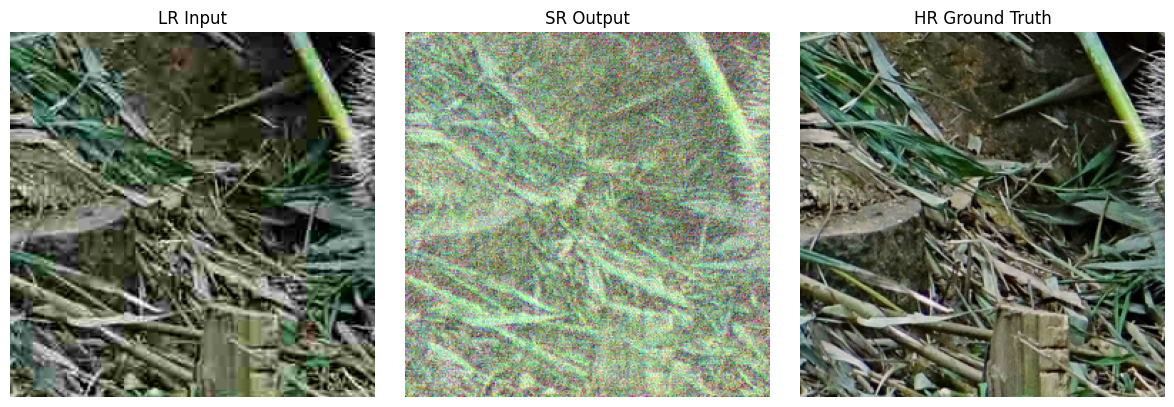

Metrics for epoch 10: Mean PSNR = 13.395901679992676, Mean SSIM = 0.1429489701986313
Saved model weights at epoch 10


Epoch 11/100 | Train Loss: 0.0129 | Val Loss: 0.0129 | PSNR: 8.73 | SSIM: 0.0284


Epoch 12/100 | Train Loss: 0.0120 | Val Loss: 0.0113 | PSNR: 8.71 | SSIM: 0.0306


Epoch 13/100 | Train Loss: 0.0110 | Val Loss: 0.0123 | PSNR: 8.95 | SSIM: 0.0323


Epoch 14/100 | Train Loss: 0.0101 | Val Loss: 0.0108 | PSNR: 8.92 | SSIM: 0.0351


...

Epoch 16/100 | Train Loss: 0.0089 | Val Loss: 0.0096 | PSNR: 9.22 | SSIM: 0.0393


Epoch 17/100 | Train Loss: 0.0085 | Val Loss: 0.0089 | PSNR: 9.21 | SSIM: 0.0396


Epoch 18/100 | Train Loss: 0.0080 | Val Loss: 0.0076 | PSNR: 9.32 | SSIM: 0.0437


Epoch 19/100 | Train Loss: 0.0077 | Val Loss: 0.0079 | PSNR: 9.37 | SSIM: 0.0486


Epoch 20/100 | Train Loss: 0.0074 | Val Loss: 0.0080 | PSNR: 9.26 | SSIM: 0.0437
Saved visualization: /content/drive/MyDrive/Rezultati/epoch_20_sample_1.png


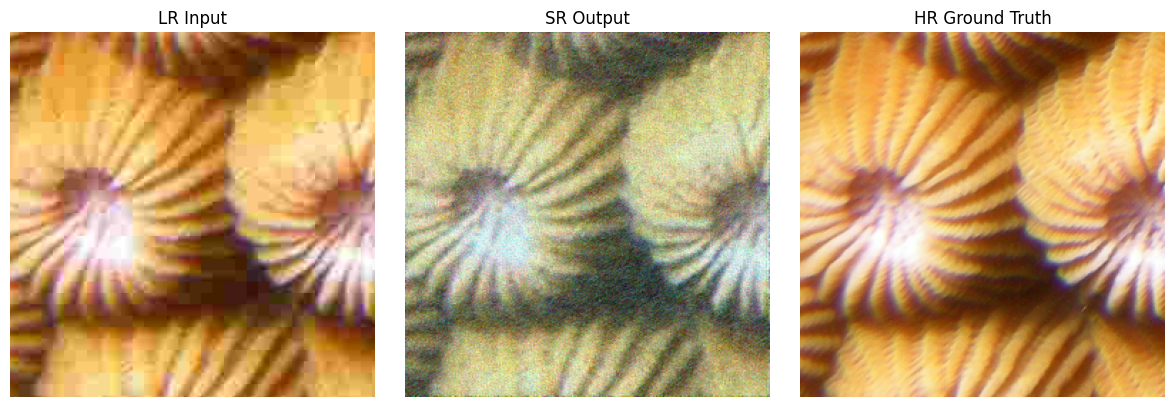

Metrics for epoch 20: Mean PSNR = 14.14283275604248, Mean SSIM = 0.28470638394355774
Saved model weights at epoch 20


Epoch 21/100 | Train Loss: 0.0071 | Val Loss: 0.0081 | PSNR: 9.49 | SSIM: 0.0493


Epoch 22/100 | Train Loss: 0.0068 | Val Loss: 0.0071 | PSNR: 9.65 | SSIM: 0.0499


Epoch 23/100 | Train Loss: 0.0066 | Val Loss: 0.0069 | PSNR: 9.68 | SSIM: 0.0522


Epoch 24/100 | Train Loss: 0.0063 | Val Loss: 0.0072 | PSNR: 9.50 | SSIM: 0.0522


...

Epoch 26/100 | Train Loss: 0.0060 | Val Loss: 0.0074 | PSNR: 9.56 | SSIM: 0.0501


Epoch 27/100 | Train Loss: 0.0057 | Val Loss: 0.0064 | PSNR: 9.73 | SSIM: 0.0595


Epoch 28/100 | Train Loss: 0.0056 | Val Loss: 0.0063 | PSNR: 9.47 | SSIM: 0.0554


Epoch 29/100 | Train Loss: 0.0054 | Val Loss: 0.0064 | PSNR: 9.86 | SSIM: 0.0585


Epoch 30/100 | Train Loss: 0.0053 | Val Loss: 0.0056 | PSNR: 9.70 | SSIM: 0.0589
Saved visualization: /content/drive/MyDrive/Rezultati/epoch_30_sample_1.png


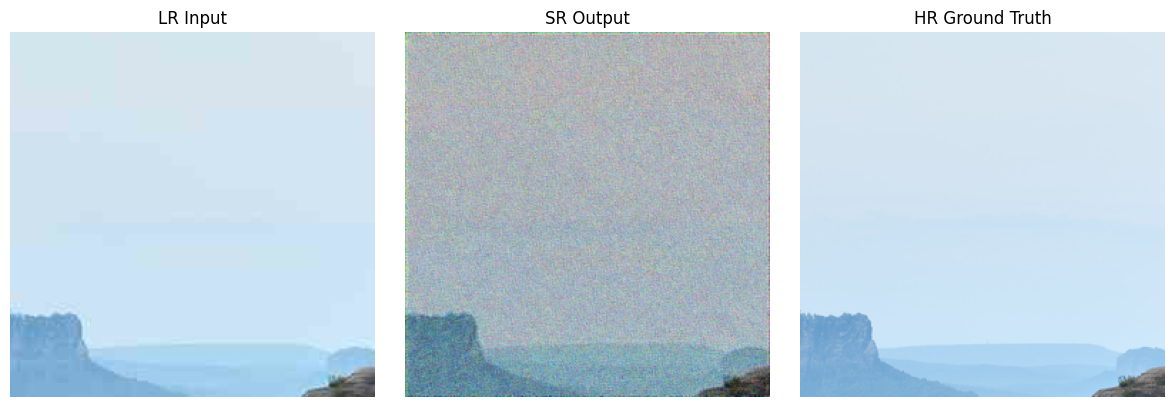

Metrics for epoch 30: Mean PSNR = 16.448701858520508, Mean SSIM = 0.39366284012794495
Saved model weights at epoch 30


Epoch 31/100 | Train Loss: 0.0053 | Val Loss: 0.0065 | PSNR: 9.87 | SSIM: 0.0568


Epoch 32/100 | Train Loss: 0.0051 | Val Loss: 0.0064 | PSNR: 9.63 | SSIM: 0.0568


Epoch 33/100 | Train Loss: 0.0051 | Val Loss: 0.0054 | PSNR: 9.73 | SSIM: 0.0584


Epoch 34/100 | Train Loss: 0.0050 | Val Loss: 0.0067 | PSNR: 9.67 | SSIM: 0.0642


...

Epoch 36/100 | Train Loss: 0.0048 | Val Loss: 0.0046 | PSNR: 9.59 | SSIM: 0.0617


Epoch 37/100 | Train Loss: 0.0048 | Val Loss: 0.0058 | PSNR: 9.68 | SSIM: 0.0617


Epoch 38/100 | Train Loss: 0.0046 | Val Loss: 0.0062 | PSNR: 9.95 | SSIM: 0.0627


Epoch 39/100 | Train Loss: 0.0045 | Val Loss: 0.0043 | PSNR: 9.56 | SSIM: 0.0572


Epoch 40/100 | Train Loss: 0.0044 | Val Loss: 0.0050 | PSNR: 10.02 | SSIM: 0.0678
Saved visualization: /content/drive/MyDrive/Rezultati/epoch_40_sample_1.png


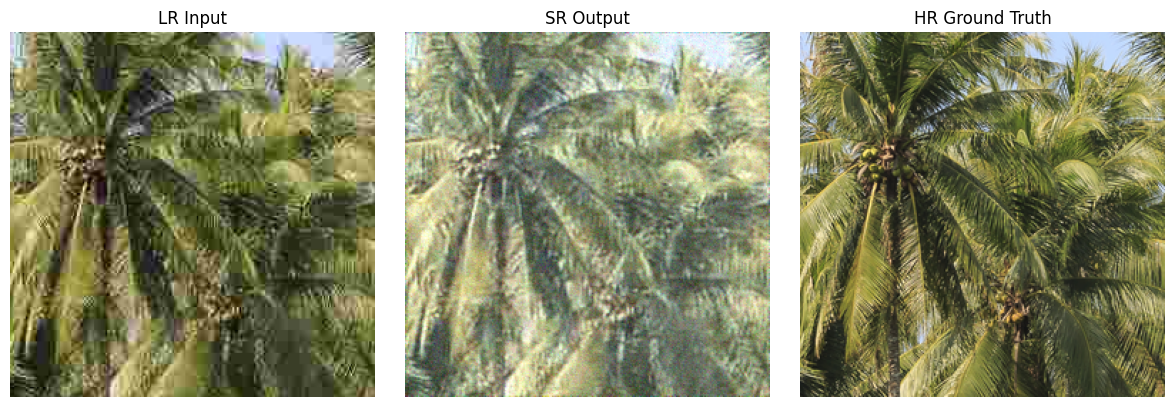

Metrics for epoch 40: Mean PSNR = 15.856999397277832, Mean SSIM = 0.5170496702194214
Saved model weights at epoch 40


Epoch 41/100 | Train Loss: 0.0043 | Val Loss: 0.0044 | PSNR: 9.98 | SSIM: 0.0608


Epoch 42/100 | Train Loss: 0.0044 | Val Loss: 0.0051 | PSNR: 9.69 | SSIM: 0.0606


Epoch 43/100 | Train Loss: 0.0042 | Val Loss: 0.0047 | PSNR: 9.62 | SSIM: 0.0602


Epoch 44/100 | Train Loss: 0.0042 | Val Loss: 0.0047 | PSNR: 9.95 | SSIM: 0.0650


...

Epoch 46/100 | Train Loss: 0.0040 | Val Loss: 0.0045 | PSNR: 9.81 | SSIM: 0.0606


Epoch 47/100 | Train Loss: 0.0040 | Val Loss: 0.0040 | PSNR: 9.75 | SSIM: 0.0604


Epoch 48/100 | Train Loss: 0.0040 | Val Loss: 0.0037 | PSNR: 9.83 | SSIM: 0.0645


Epoch 49/100 | Train Loss: 0.0040 | Val Loss: 0.0056 | PSNR: 9.94 | SSIM: 0.0637


Epoch 50/100 | Train Loss: 0.0039 | Val Loss: 0.0044 | PSNR: 9.65 | SSIM: 0.0604
Saved visualization: /content/drive/MyDrive/Rezultati/epoch_50_sample_1.png


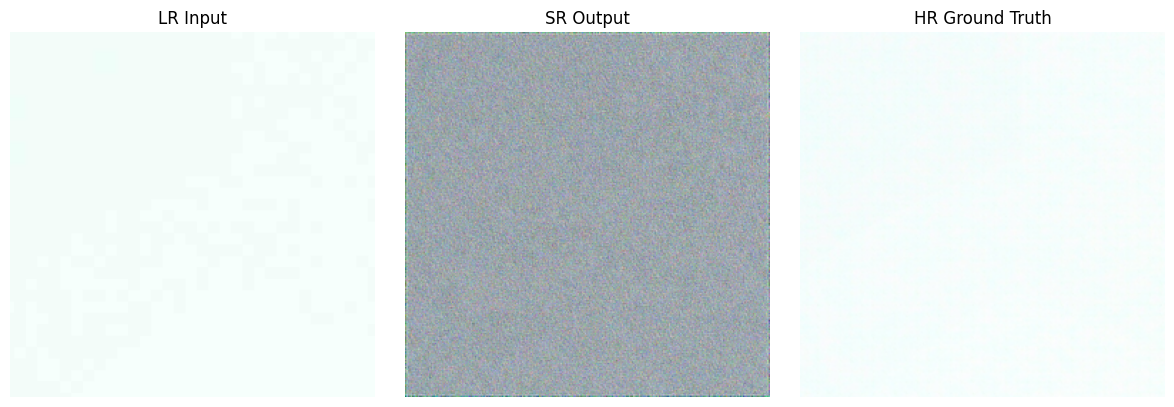

Metrics for epoch 50: Mean PSNR = 13.603865623474121, Mean SSIM = 0.5008901953697205
Saved model weights at epoch 50


Epoch 51/100 | Train Loss: 0.0037 | Val Loss: 0.0038 | PSNR: 9.85 | SSIM: 0.0689


Epoch 52/100 | Train Loss: 0.0038 | Val Loss: 0.0040 | PSNR: 9.77 | SSIM: 0.0629


Epoch 53/100 | Train Loss: 0.0037 | Val Loss: 0.0044 | PSNR: 9.82 | SSIM: 0.0638


Epoch 54/100 | Train Loss: 0.0035 | Val Loss: 0.0039 | PSNR: 9.90 | SSIM: 0.0575


...

Epoch 56/100 | Train Loss: 0.0035 | Val Loss: 0.0039 | PSNR: 9.85 | SSIM: 0.0638


Epoch 57/100 | Train Loss: 0.0035 | Val Loss: 0.0034 | PSNR: 9.65 | SSIM: 0.0624


Epoch 58/100 | Train Loss: 0.0034 | Val Loss: 0.0031 | PSNR: 9.49 | SSIM: 0.0545


Epoch 59/100 | Train Loss: 0.0034 | Val Loss: 0.0035 | PSNR: 9.49 | SSIM: 0.0566


Epoch 60/100 | Train Loss: 0.0032 | Val Loss: 0.0033 | PSNR: 9.66 | SSIM: 0.0596
Saved visualization: /content/drive/MyDrive/Rezultati/epoch_60_sample_1.png


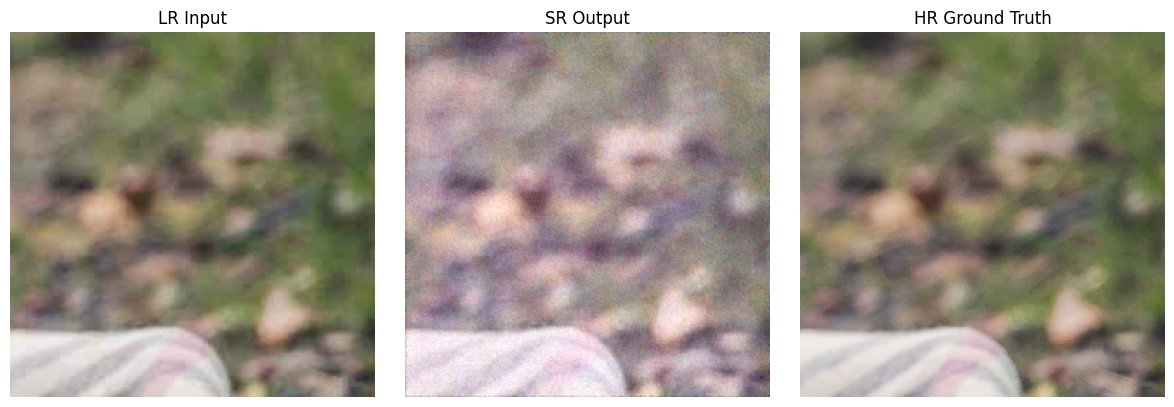

Metrics for epoch 60: Mean PSNR = 15.458455085754395, Mean SSIM = 0.5205071568489075
Saved model weights at epoch 60


KeyboardInterrupt: 

In [32]:
print("Starting training...")

for epoch in range(epochs):
    train_bar = tqdm(train_dataset.take(steps_per_epoch), total=steps_per_epoch, desc="Training", leave=False)
    total_train_loss = 0

    for i, (lr_batch, hr_batch) in enumerate(train_bar):
        loss = train_step(hr_batch, lr_batch, model, timesteps,
                          buffers['sqrt_alphas_cumprod'], buffers['sqrt_one_minus_alphas_cumprod'])
        total_train_loss += loss
        train_bar.set_postfix(loss=float(loss))

    avg_train_loss = total_train_loss / steps_per_epoch

    total_val_loss = 0
    val_steps = 100
    val_bar = tqdm(valid_dataset.take(val_steps), total=val_steps, desc="Validation", leave=False)

    all_psnr, all_ssim = [], []

    for lr_batch, hr_batch in val_bar:
        val_loss = validation_step(hr_batch, lr_batch, model, timesteps,
                                   buffers['sqrt_alphas_cumprod'], buffers['sqrt_one_minus_alphas_cumprod'])
        total_val_loss += val_loss

        sr_batch = sr3_sampling(lr_batch, model, timesteps, sampling_steps=50)
        psnr_batch = tf.image.psnr(sr_batch, hr_batch, max_val=1.0)
        ssim_batch = tf.image.ssim(sr_batch, hr_batch, max_val=1.0)

        all_psnr.extend(psnr_batch.numpy())
        all_ssim.extend(ssim_batch.numpy())

        val_bar.set_postfix(val_loss=float(val_loss))

    avg_val_loss = total_val_loss / val_steps
    mean_psnr = np.mean(all_psnr)
    mean_ssim = np.mean(all_ssim)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | PSNR: {mean_psnr:.2f} | SSIM: {mean_ssim:.4f}")

    if (epoch + 1) % 10 == 0:
        visualize_sample(model, train_dataset, timesteps, epoch=epoch, save_dir="/content/drive/MyDrive/Rezultati/")
        model.save_weights(f"/content/drive/MyDrive/Weights/model_weights_epoch_{epoch+1}.weights.h5")
        print(f"Saved model weights at epoch {epoch+1}")

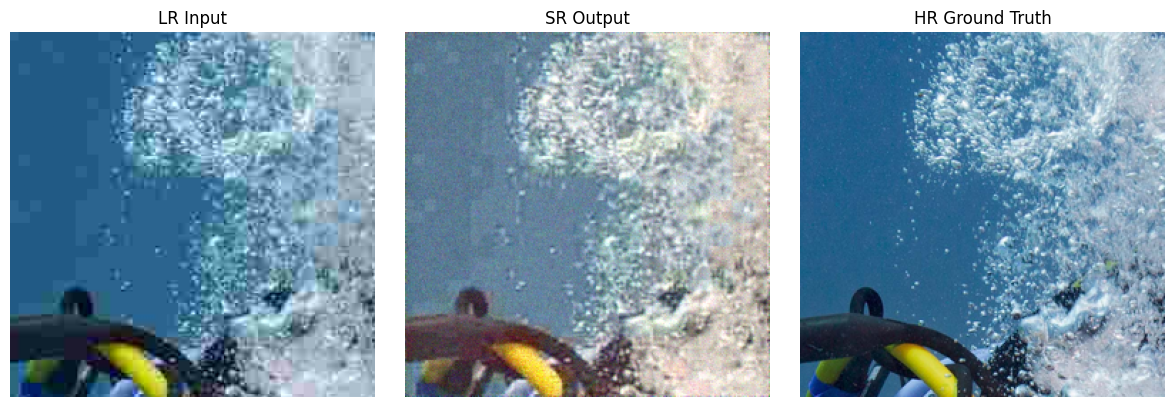

Metrics for epoch ?: Mean PSNR = 10.954963684082031, Mean SSIM = 0.3483583927154541


In [42]:
visualize_sample(model, test_dataset, timesteps=1000)